# <div dir = 'rtl'>تمرین سوم  یادگیری عمیق</div>

# <div dir = 'rtl'>کتابخانه های لازم</div>

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import os
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# <div dir = 'rtl'>بارگذاری داده ها </div>

In [2]:
train_dataset = datasets.CIFAR10(root="./cifar-10-python", train=True, download=False)
test_dataset = datasets.CIFAR10(root="./cifar-10-python", train=False, download=False)
print(len(train_dataset))
print(len(test_dataset))

50000
10000


# <div dir = 'rtl'>تنظیمات جهت تکرار پذیری کد </div>

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# <div dir = 'rtl'>استاندارد سازی داده ها </div>

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean,std)])
train_dataset.transform = transform
test_dataset.transform = transform

# <div dir = 'rtl'>اطلاعات داده ها </div>

In [6]:
classes = train_dataset.classes
print("Classes:")
print(classes)
print("\nNumber of training samples:")
print(len(train_dataset))
print("\nNumber of test samples:")
print(len(test_dataset))
sample_img, sample_label = train_dataset[0]
print("\nImage shape:")
print(sample_img.shape)
print("\nImage dtype:")
print(sample_img.dtype)

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Number of training samples:
50000

Number of test samples:
10000

Image shape:
torch.Size([3, 32, 32])

Image dtype:
torch.float32


In [7]:
targets = train_dataset.targets
indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(indices,test_size=5000,stratify=targets,random_state=SEED)
train_sub = Subset(train_dataset, train_idx)
val_sub =Subset(train_dataset, val_idx)
print("\nFinal Train Size:", len(train_sub))
print("Validation Size :", len(val_sub))


Final Train Size: 45000
Validation Size : 5000


In [8]:
trian_labels = np.array(targets)[train_idx]
val_labels = np.array(targets)[val_idx]
print('Check Class Distribution')
for i,cls in enumerate(classes):
    print(cls, np.sum( trian_labels==i ))
print(8*'-')
for i,cls in enumerate(classes):
    print(cls, np.sum( val_labels==i ))

Check Class Distribution
airplane 4500
automobile 4500
bird 4500
cat 4500
deer 4500
dog 4500
frog 4500
horse 4500
ship 4500
truck 4500
--------
airplane 500
automobile 500
bird 500
cat 500
deer 500
dog 500
frog 500
horse 500
ship 500
truck 500


# <div dir = 'rtl'>نمایش داده های یادگیری</div>

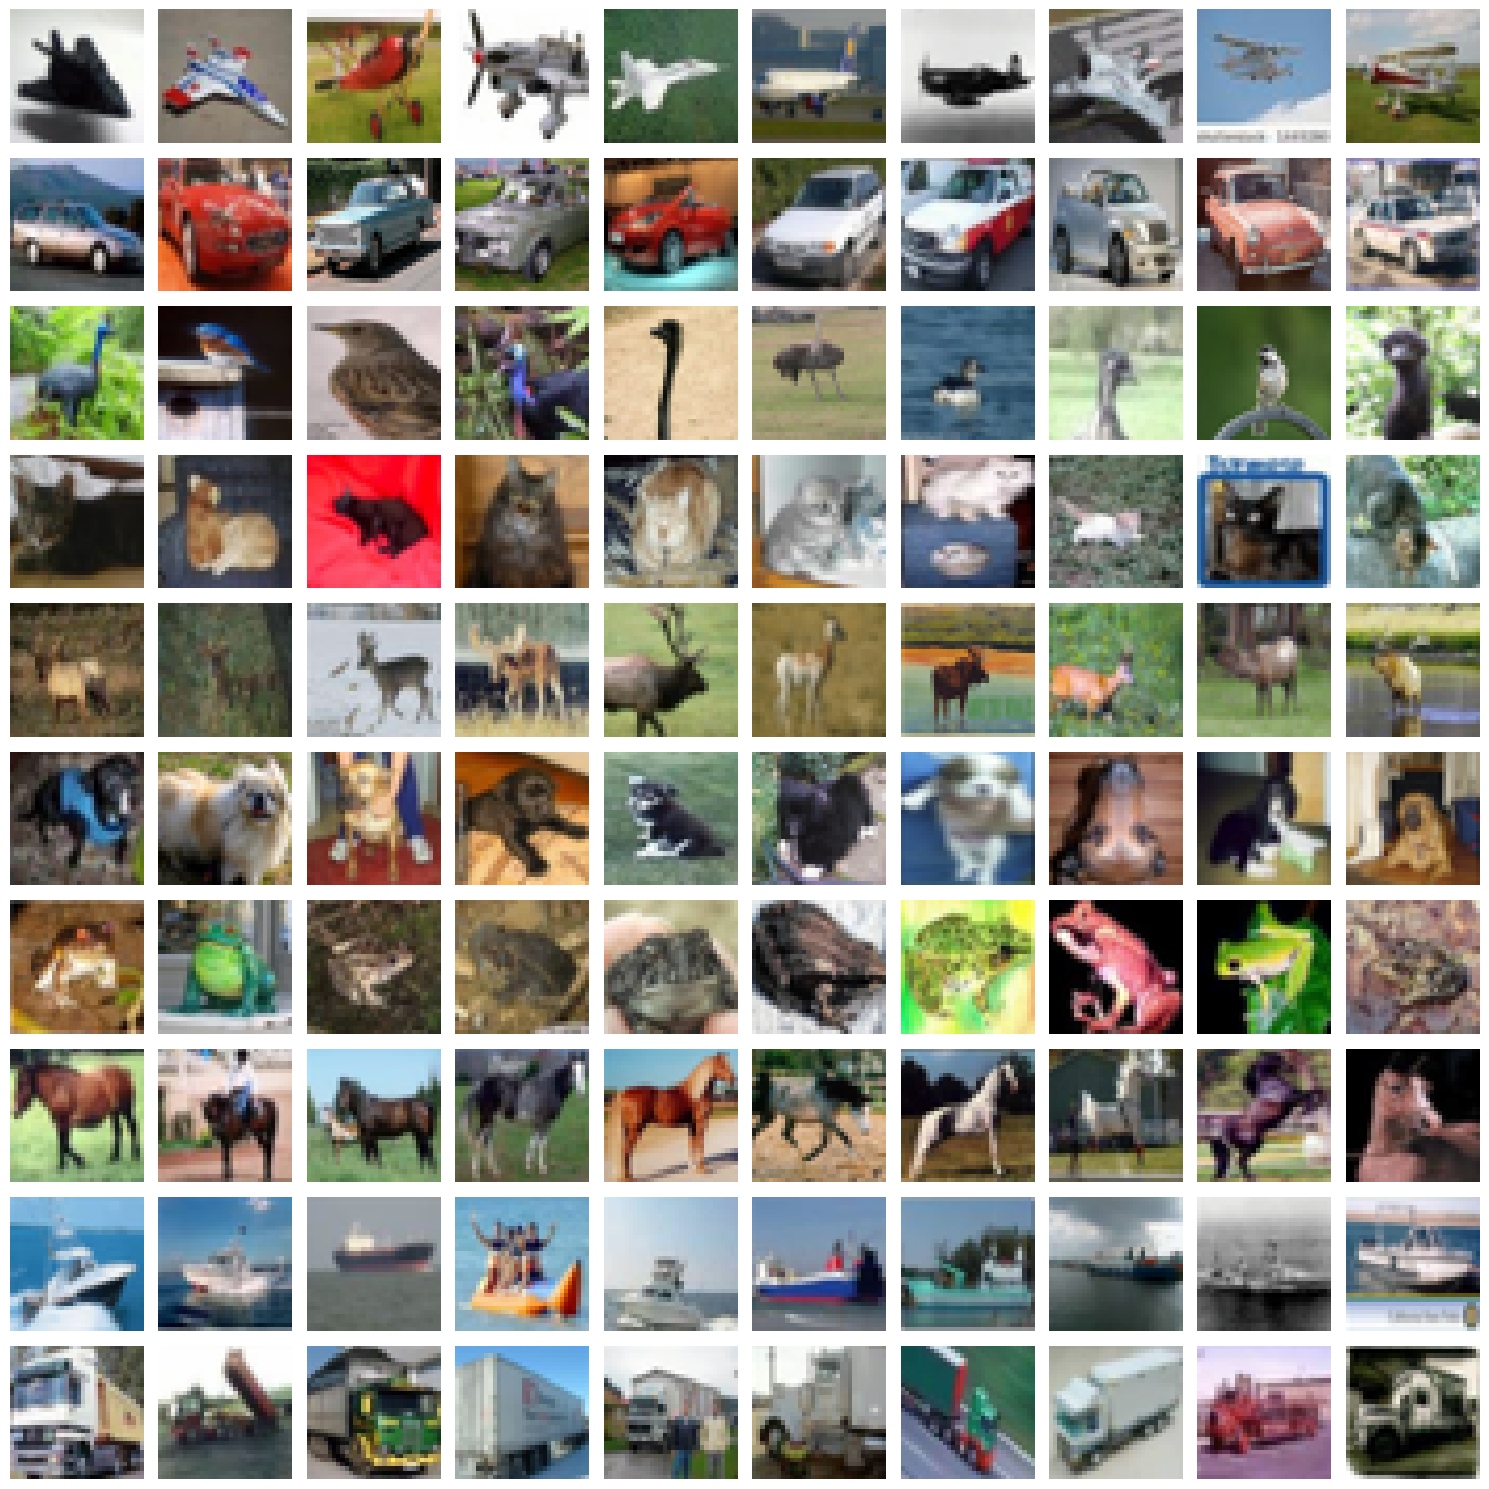

In [9]:
fig, axes = plt.subplots(
    nrows=10,
    ncols=10,
    figsize=(15,15)
)

class_counter = {i:0 for i in range(10)}

for img, label in train_dataset:

    if class_counter[label] < 10:

        row = label
        col = class_counter[label]

        image = img.numpy().transpose(1,2,0)

        image = image * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)
        image = np.clip(image, 0, 1)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                classes[label],
                fontsize=10
            )

        class_counter[label] += 1

    if all(v == 10 for v in class_counter.values()):
        break

plt.tight_layout()
plt.show()

In [10]:
train_original_counts = Counter(train_dataset.targets)
train_final_labels = np.array(train_dataset.targets)[train_idx]
train_final_counts = Counter(train_final_labels)
val_labels = np.array(train_dataset.targets)[val_idx]
val_counts = Counter(val_labels)
test_counts = Counter(test_dataset.targets)

distribution_df = pd.DataFrame({
    "Class": classes,
    "Train Original": [train_original_counts[i] for i in range(10)],
    "Train Final": [train_final_counts[i] for i in range(10)],
    "Validation": [val_counts[i] for i in range(10)],
    "Test": [test_counts[i] for i in range(10)]
})
distribution_df

,Class,Train Original,Train Final,Validation,Test
0,airplane,5000,4500,500,1000
1,automobile,5000,4500,500,1000
2,bird,5000,4500,500,1000
3,cat,5000,4500,500,1000
4,deer,5000,4500,500,1000
5,dog,5000,4500,500,1000
6,frog,5000,4500,500,1000
7,horse,5000,4500,500,1000
8,ship,5000,4500,500,1000
9,truck,5000,4500,500,1000


In [11]:
os.makedirs('output',exist_ok=True)

In [12]:
distribution_df.to_csv('output/class_distribution.csv',index=False)

# <div dir = 'rtl'>توزیع داده ها بعد از تقسیم </div>

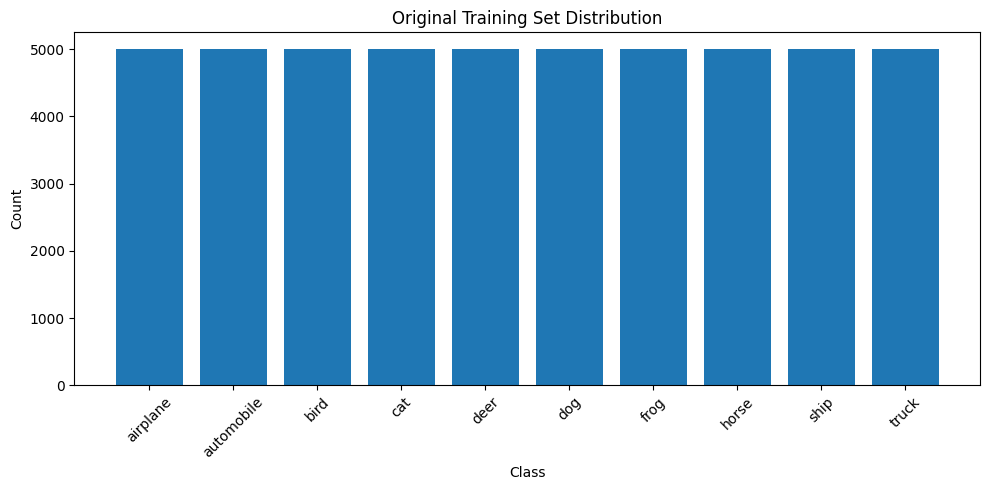

In [13]:
plt.figure(figsize=(10,5))
plt.bar(distribution_df["Class"], distribution_df["Train Original"])
plt.title("Original Training Set Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/fig_1.png')
plt.show()

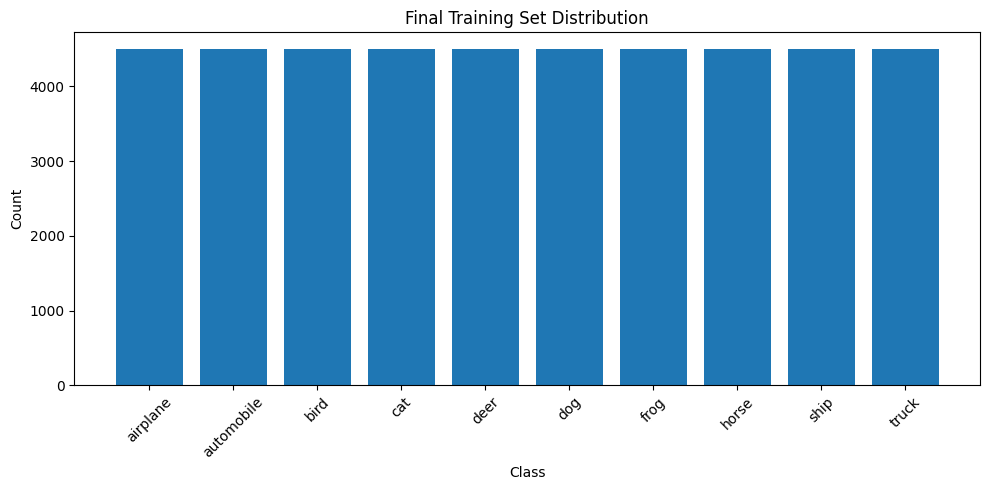

In [14]:
plt.figure(figsize=(10,5))
plt.bar(distribution_df["Class"], distribution_df["Train Final"])
plt.title("Final Training Set Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/fig_2.png')
plt.show()

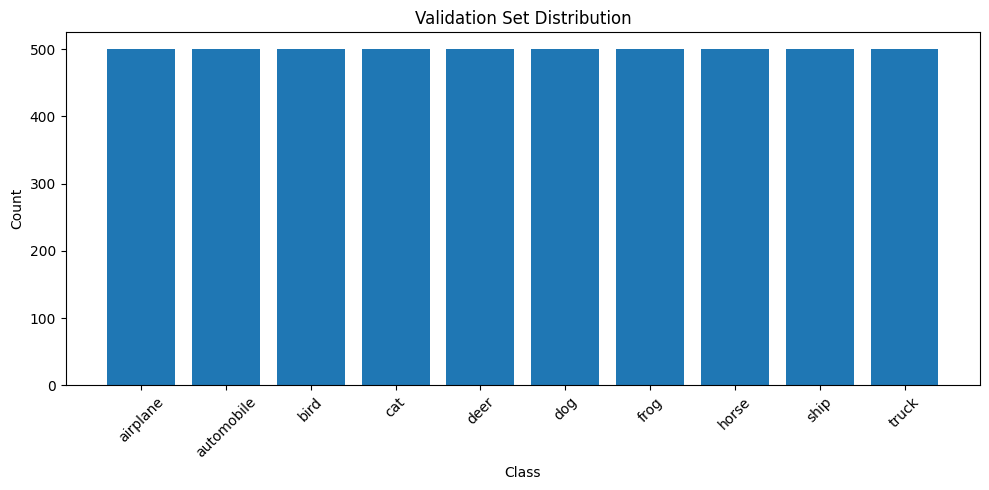

In [15]:
plt.figure(figsize=(10,5))
plt.bar(distribution_df["Class"], distribution_df["Validation"])
plt.title("Validation Set Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/fig_3.png')
plt.show()

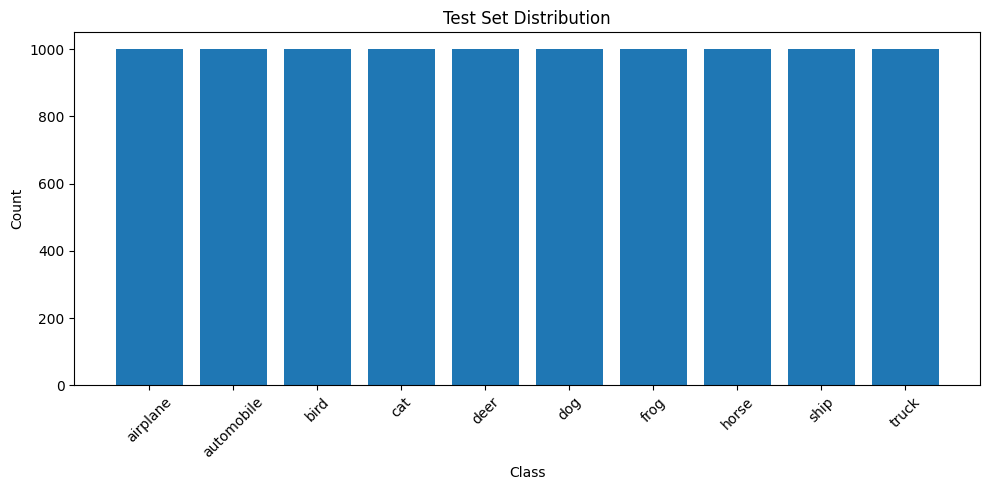

In [16]:
plt.figure(figsize=(10,5))
plt.bar(distribution_df["Class"],distribution_df["Test"])
plt.title("Test Set Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/fig_4.png')
plt.show()

# <div dir = 'rtl'>ساخت و آموزش مدل CNN_1</div>

In [17]:
BATCH_SIZE = 128
train_loader = DataLoader(train_sub, batch_size= BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [18]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])


In [19]:
class CNN_1(nn.Module):

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels = 3,
                out_channels = 32,
                kernel_size = 3,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels = 32,
                out_channels = 64,
                kernel_size = 3,
                padding =1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 8 * 8,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )
        )
    def forward(self, x):
    
        x = self.features(x)

        x = self.classifier(x)

        return x

In [20]:
device = torch.device("cuda")

In [21]:
model_1 = CNN_1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_1.parameters(),
    lr=1e-3
)

In [22]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc

In [23]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc

In [24]:
EPOCHS = 20

train_losses = []
train_accs = []

val_losses = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_1,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model_1,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] Train Loss: 1.3924 Train Acc: 0.5043 Val Loss: 1.1057 Val Acc: 0.6058
Epoch [2/20] Train Loss: 0.9987 Train Acc: 0.6503 Val Loss: 0.9912 Val Acc: 0.6440
Epoch [3/20] Train Loss: 0.8376 Train Acc: 0.7071 Val Loss: 0.8649 Val Acc: 0.6924
Epoch [4/20] Train Loss: 0.7280 Train Acc: 0.7460 Val Loss: 0.8322 Val Acc: 0.7116
Epoch [5/20] Train Loss: 0.6278 Train Acc: 0.7813 Val Loss: 0.9182 Val Acc: 0.6850
Epoch [6/20] Train Loss: 0.5422 Train Acc: 0.8102 Val Loss: 0.8252 Val Acc: 0.7254
Epoch [7/20] Train Loss: 0.4632 Train Acc: 0.8395 Val Loss: 0.8546 Val Acc: 0.7196
Epoch [8/20] Train Loss: 0.3850 Train Acc: 0.8659 Val Loss: 0.9307 Val Acc: 0.7072
Epoch [9/20] Train Loss: 0.3139 Train Acc: 0.8912 Val Loss: 0.9548 Val Acc: 0.7274
Epoch [10/20] Train Loss: 0.2457 Train Acc: 0.9172 Val Loss: 0.9921 Val Acc: 0.7188
Epoch [11/20] Train Loss: 0.1990 Train Acc: 0.9310 Val Loss: 1.0972 Val Acc: 0.7242
Epoch [12/20] Train Loss: 0.1568 Train Acc: 0.9480 Val Loss: 1.2152 Val Acc: 0.7256
E

# <div dir = 'rtl'>ساخت و آموزش مدل CNN_2</div>

In [25]:
class CNN_2 (nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 8 * 8,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10 )
        )
    def forward(self,x):
        x = self.features(x)

        x = self.classifier(x)

        return x

In [26]:
model_2 = CNN_2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(),lr=1e-3,weight_decay=1e-4)

In [27]:
EPOCHS = 20

train_losses_1 = []
train_accs_1 = []

val_losses_1 = []
val_accs_1 = []

for epoch in range(EPOCHS):

    train_loss_1, train_acc_1 = train_one_epoch(
        model_2,
        train_loader,
        criterion,
        optimizer_2,
        device
    )

    val_loss_1, val_acc_1 = evaluate(
        model_2,
        val_loader,
        criterion,
        device
    )

    train_losses_1.append(train_loss_1)
    train_accs_1.append(train_acc_1)

    val_losses_1.append(val_loss_1)
    val_accs_1.append(val_acc_1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss_1:.4f} "
        f"Train Acc: {train_acc_1:.4f} "
        f"Val Loss: {val_loss_1:.4f} "
        f"Val Acc: {val_acc_1:.4f}"
    )

Epoch [1/20] Train Loss: 1.5127 Train Acc: 0.4482 Val Loss: 1.1795 Val Acc: 0.5764
Epoch [2/20] Train Loss: 1.1350 Train Acc: 0.5947 Val Loss: 0.9789 Val Acc: 0.6544
Epoch [3/20] Train Loss: 0.9896 Train Acc: 0.6497 Val Loss: 0.8447 Val Acc: 0.7014
Epoch [4/20] Train Loss: 0.9008 Train Acc: 0.6829 Val Loss: 0.7567 Val Acc: 0.7348
Epoch [5/20] Train Loss: 0.8521 Train Acc: 0.7031 Val Loss: 0.7952 Val Acc: 0.7084
Epoch [6/20] Train Loss: 0.8029 Train Acc: 0.7213 Val Loss: 0.7485 Val Acc: 0.7320
Epoch [7/20] Train Loss: 0.7700 Train Acc: 0.7297 Val Loss: 0.6498 Val Acc: 0.7694
Epoch [8/20] Train Loss: 0.7364 Train Acc: 0.7437 Val Loss: 0.6862 Val Acc: 0.7614
Epoch [9/20] Train Loss: 0.7145 Train Acc: 0.7513 Val Loss: 0.7347 Val Acc: 0.7280
Epoch [10/20] Train Loss: 0.6794 Train Acc: 0.7635 Val Loss: 0.6137 Val Acc: 0.7776
Epoch [11/20] Train Loss: 0.6570 Train Acc: 0.7683 Val Loss: 0.6779 Val Acc: 0.7640
Epoch [12/20] Train Loss: 0.6409 Train Acc: 0.7761 Val Loss: 0.6062 Val Acc: 0.7830
E

# <div dir = 'rtl'>مقایسه دو مدل</div>

In [28]:
comparison_df = pd.DataFrame({

    "Model":[
        "CNN-1",
        "CNN-2"
    ],

    "Best Validation Accuracy":[
        max(val_accs),
        max(val_accs_1)
    ]
})

comparison_df

,Model,Best Validation Accuracy
0,CNN-1,0.7274
1,CNN-2,0.8190


In [29]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print("CNN-1 Parameters:",
      count_parameters(model_1))

print("CNN-2 Parameters:",
      count_parameters(model_2))

CNN-1 Parameters: 545098
CNN-2 Parameters: 1117354


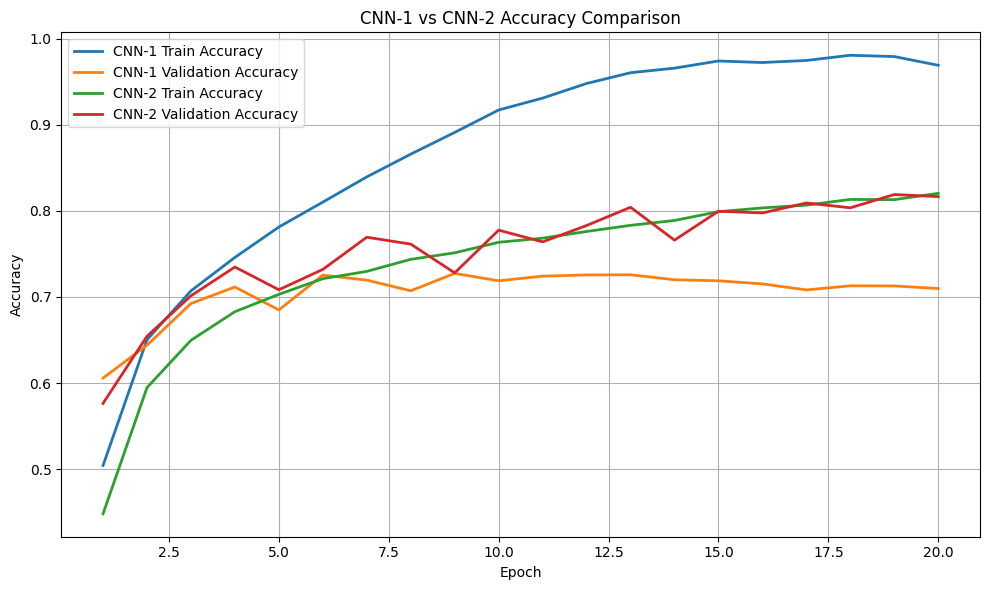

In [30]:
plt.figure(figsize=(10,6))

epochs = range(1, len(train_accs)+1)

plt.plot(
    epochs,
    train_accs,
    label="CNN-1 Train Accuracy",
    linewidth=2
)

plt.plot(
    epochs,
    val_accs,
    label="CNN-1 Validation Accuracy",
    linewidth=2
)

plt.plot(
    epochs,
    train_accs_1,
    label="CNN-2 Train Accuracy",
    linewidth=2
)

plt.plot(
    epochs,
    val_accs_1,
    label="CNN-2 Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN-1 vs CNN-2 Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/cnn_comparison_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

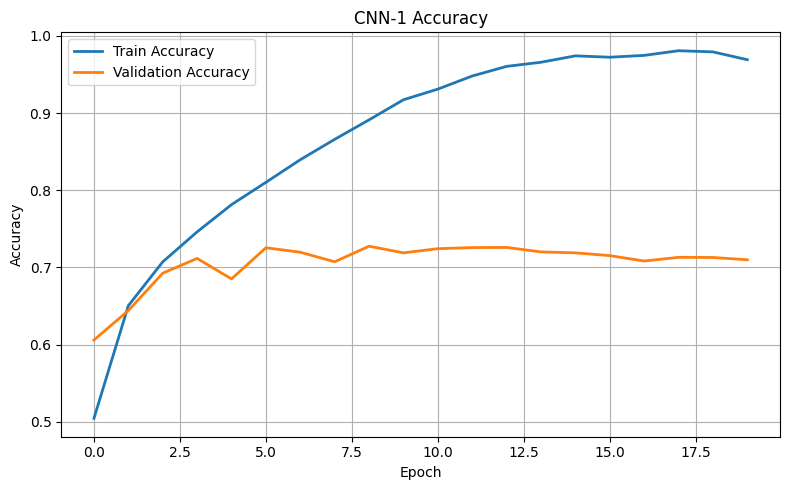

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    val_accs,
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN-1 Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/cnn1_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

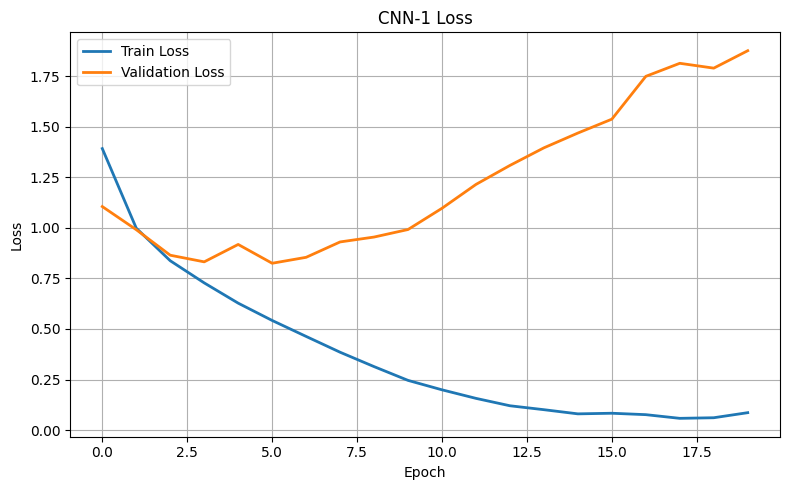

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("CNN-1 Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/cnn1_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

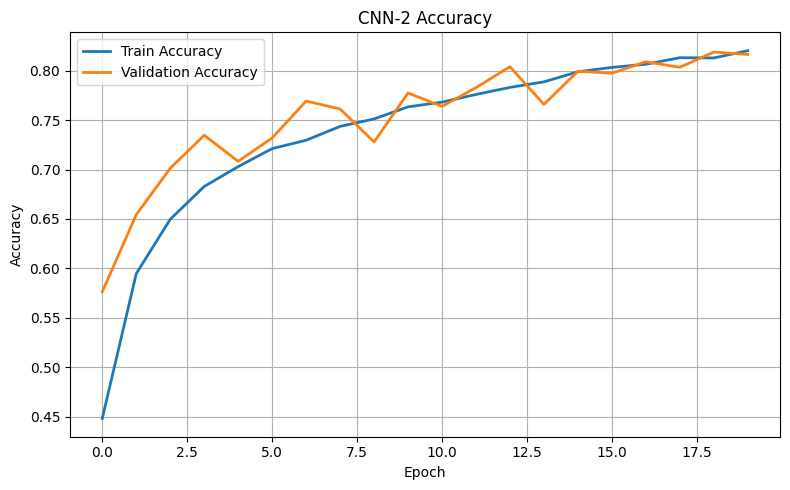

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs_1,
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    val_accs_1,
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN-2 Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/cnn2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

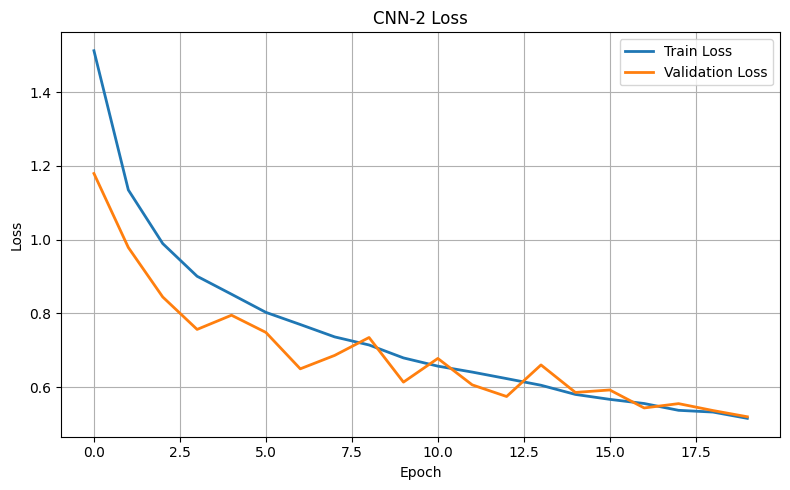

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_1,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    val_losses_1,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("CNN-2 Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "output/cnn2_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# <div dir = 'rtl'>پیش بینی روی مدل بهتر</div>

In [35]:
y_true = []
y_pred = []

model_2.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_2(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predicted.cpu().numpy()
        )

In [36]:
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Accuracy       : {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall   : {test_recall:.4f}")
print(f"Macro F1-score : {test_f1:.4f}")

Accuracy       : 0.8094
Macro Precision: 0.8134
Macro Recall   : 0.8094
Macro F1-score : 0.8102


In [37]:
results_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Value":[
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

results_df.to_csv(
    "output/final_metrics.csv",
    index=False
)

results_df

,Metric,Value
0,Accuracy,0.809400
1,Macro Precision,0.813412
2,Macro Recall,0.809400
3,Macro F1,0.810231


# <div dir = 'rtl'>ماتریس در هم ریختگی</div>

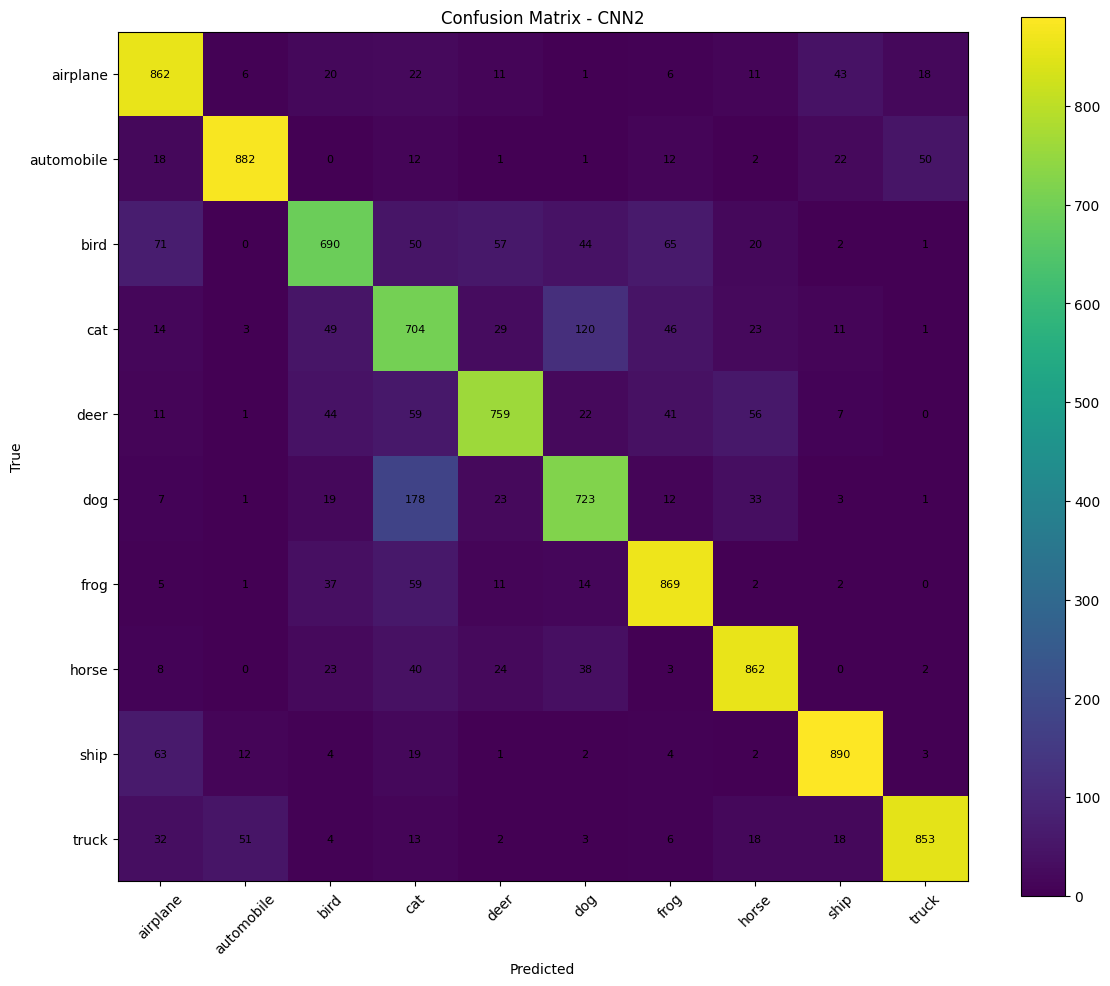

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)
plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.xticks(
    np.arange(10),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(10),
    classes
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix - CNN2")

plt.tight_layout()

plt.savefig(
    "output/confusion_matrix_numbers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# <div dir = 'rtl'>تنظیم محدود هایپر پارامتر ها </div>

In [39]:
train_loader_64 = DataLoader(
    train_sub,
    batch_size=64,
    shuffle=True
)

val_loader_64 = DataLoader(
    val_sub,
    batch_size=64,
    shuffle=False
)

In [40]:
model_exp2 = CNN_1().to(device)

optimizer_exp2 = torch.optim.Adam(
    model_exp2.parameters(),
    lr=5e-4
)

In [41]:
model_exp3 = CNN_2().to(device)

optimizer_exp3 = torch.optim.Adam(
    model_exp3.parameters(),
    lr=1e-3
)

In [42]:
model_exp5 = CNN_2().to(device)

optimizer_exp5 = torch.optim.Adam(
    model_exp5.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [43]:
model_exp6 = CNN_2().to(device)

optimizer_exp6 = torch.optim.SGD(
    model_exp6.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

In [44]:
def evaluate_f1(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = accuracy_score(
        y_true,
        y_pred
    )

    epoch_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    return epoch_loss, epoch_acc, epoch_f1

In [45]:
train_loss_cnn1, train_acc_cnn1, train_f1_cnn1 = evaluate_f1(
    model_1,
    train_loader,
    criterion,
    device
)

val_loss_cnn1, val_acc_cnn1, val_f1_cnn1 = evaluate_f1(
    model_1,
    val_loader,
    criterion,
    device
)

print("CNN-1")

print("Train Accuracy :", train_acc_cnn1)
print("Train F1       :", train_f1_cnn1)

print("Validation Accuracy :", val_acc_cnn1)
print("Validation F1       :", val_f1_cnn1)

CNN-1
Train Accuracy : 0.9836888888888888
Train F1       : 0.9836918383128597
Validation Accuracy : 0.7098
Validation F1       : 0.7104189769552336


In [46]:
train_loss_cnn2, train_acc_cnn2, train_f1_cnn2 = evaluate_f1(
    model_2,
    train_loader,
    criterion,
    device
)

val_loss_cnn2, val_acc_cnn2, val_f1_cnn2 = evaluate_f1(
    model_2,
    val_loader,
    criterion,
    device
)

print("CNN-2")

print("Train Accuracy :", train_acc_cnn2)
print("Train F1       :", train_f1_cnn2)

print("Validation Accuracy :", val_acc_cnn2)
print("Validation F1       :", val_f1_cnn2)

CNN-2
Train Accuracy : 0.8963777777777778
Train F1       : 0.8967953196752928
Validation Accuracy : 0.8166
Validation F1       : 0.8172276204969668


In [47]:
def run_experiment(
    model,
    optimizer,
    train_loader_used,
    val_loader_used,
    epochs=20,
    patience=5
):

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_result = None

    best_val_acc = 0

    early_stop_counter = 0

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader_used,
            criterion,
            optimizer,
            device
        )

        train_eval_loss, train_eval_acc, train_f1 = evaluate_f1(
            model,
            train_loader_used,
            criterion,
            device
        )

        val_loss, val_acc, val_f1 = evaluate_f1(
            model,
            val_loader_used,
            criterion,
            device
        )

        scheduler.step(val_acc)

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            early_stop_counter = 0

            best_result = {

                "train_acc": train_eval_acc,
                "val_acc": val_acc,

                "train_f1": train_f1,
                "val_f1": val_f1
            }

        else:

            early_stop_counter += 1

        if early_stop_counter >= patience:

            print(
                f"Early Stopping at Epoch {epoch+1}"
            )

            break

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

    return best_result

In [48]:
model_exp2 = CNN_1().to(device)

optimizer_exp2 = torch.optim.Adam(
    model_exp2.parameters(),
    lr=5e-4
)

result_exp2 = run_experiment(
    model_exp2,
    optimizer_exp2,
    train_loader_64,
    val_loader_64
)

Epoch [1/20] Train Loss: 1.4054 Train Acc: 0.5013 Val Loss: 1.1571 Val Acc: 0.5900
Epoch [2/20] Train Loss: 1.0389 Train Acc: 0.6342 Val Loss: 1.0143 Val Acc: 0.6452
Epoch [3/20] Train Loss: 0.8967 Train Acc: 0.6882 Val Loss: 0.9312 Val Acc: 0.6764
Epoch [4/20] Train Loss: 0.7890 Train Acc: 0.7248 Val Loss: 0.8491 Val Acc: 0.7024
Epoch [5/20] Train Loss: 0.7039 Train Acc: 0.7542 Val Loss: 0.8510 Val Acc: 0.6978
Epoch [6/20] Train Loss: 0.6181 Train Acc: 0.7853 Val Loss: 0.8107 Val Acc: 0.7184
Epoch [7/20] Train Loss: 0.5466 Train Acc: 0.8103 Val Loss: 0.8049 Val Acc: 0.7228
Epoch [8/20] Train Loss: 0.4757 Train Acc: 0.8349 Val Loss: 0.8479 Val Acc: 0.7242
Epoch [9/20] Train Loss: 0.4080 Train Acc: 0.8591 Val Loss: 0.8791 Val Acc: 0.7236
Epoch [10/20] Train Loss: 0.3434 Train Acc: 0.8832 Val Loss: 0.9348 Val Acc: 0.7204
Epoch [11/20] Train Loss: 0.2888 Train Acc: 0.9024 Val Loss: 0.9593 Val Acc: 0.7244
Epoch [12/20] Train Loss: 0.2411 Train Acc: 0.9200 Val Loss: 1.0028 Val Acc: 0.7214
E

In [49]:
model_exp3 = CNN_2().to(device)

optimizer_exp3 = torch.optim.Adam(
    model_exp3.parameters(),
    lr=1e-3
)

result_exp3 = run_experiment(
    model_exp3,
    optimizer_exp3,
    train_loader,
    val_loader
)

Epoch [1/20] Train Loss: 1.5110 Train Acc: 0.4516 Val Loss: 1.1506 Val Acc: 0.5906
Epoch [2/20] Train Loss: 1.1403 Train Acc: 0.5934 Val Loss: 0.9489 Val Acc: 0.6614
Epoch [3/20] Train Loss: 1.0052 Train Acc: 0.6453 Val Loss: 0.8576 Val Acc: 0.6934
Epoch [4/20] Train Loss: 0.9232 Train Acc: 0.6756 Val Loss: 0.7860 Val Acc: 0.7266
Epoch [5/20] Train Loss: 0.8681 Train Acc: 0.6976 Val Loss: 0.7560 Val Acc: 0.7274
Epoch [6/20] Train Loss: 0.8292 Train Acc: 0.7112 Val Loss: 0.7017 Val Acc: 0.7524
Epoch [7/20] Train Loss: 0.7930 Train Acc: 0.7229 Val Loss: 0.6648 Val Acc: 0.7610
Epoch [8/20] Train Loss: 0.7577 Train Acc: 0.7330 Val Loss: 0.7000 Val Acc: 0.7576
Epoch [9/20] Train Loss: 0.7336 Train Acc: 0.7460 Val Loss: 0.6388 Val Acc: 0.7774
Epoch [10/20] Train Loss: 0.7076 Train Acc: 0.7525 Val Loss: 0.6390 Val Acc: 0.7764
Epoch [11/20] Train Loss: 0.6901 Train Acc: 0.7584 Val Loss: 0.6997 Val Acc: 0.7540
Epoch [12/20] Train Loss: 0.6645 Train Acc: 0.7668 Val Loss: 0.6503 Val Acc: 0.7694
E

In [50]:
model_exp5 = CNN_2().to(device)

optimizer_exp5 = torch.optim.Adam(
    model_exp5.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

result_exp5 = run_experiment(
    model_exp5,
    optimizer_exp5,
    train_loader_64,
    val_loader_64
)

Epoch [1/20] Train Loss: 1.4512 Train Acc: 0.4731 Val Loss: 1.0930 Val Acc: 0.6102
Epoch [2/20] Train Loss: 1.0887 Train Acc: 0.6122 Val Loss: 0.8971 Val Acc: 0.6796
Epoch [3/20] Train Loss: 0.9585 Train Acc: 0.6620 Val Loss: 0.7786 Val Acc: 0.7240
Epoch [4/20] Train Loss: 0.8742 Train Acc: 0.6918 Val Loss: 0.7326 Val Acc: 0.7404
Epoch [5/20] Train Loss: 0.8178 Train Acc: 0.7120 Val Loss: 0.7486 Val Acc: 0.7346
Epoch [6/20] Train Loss: 0.7786 Train Acc: 0.7278 Val Loss: 0.6458 Val Acc: 0.7718
Epoch [7/20] Train Loss: 0.7503 Train Acc: 0.7364 Val Loss: 0.6483 Val Acc: 0.7728
Epoch [8/20] Train Loss: 0.7175 Train Acc: 0.7479 Val Loss: 0.6352 Val Acc: 0.7756
Epoch [9/20] Train Loss: 0.6929 Train Acc: 0.7560 Val Loss: 0.6573 Val Acc: 0.7626
Epoch [10/20] Train Loss: 0.6731 Train Acc: 0.7640 Val Loss: 0.6062 Val Acc: 0.7836
Epoch [11/20] Train Loss: 0.6407 Train Acc: 0.7747 Val Loss: 0.6312 Val Acc: 0.7818
Epoch [12/20] Train Loss: 0.6216 Train Acc: 0.7816 Val Loss: 0.5707 Val Acc: 0.7986
E

In [51]:
model_exp6 = CNN_2().to(device)

optimizer_exp6 = torch.optim.SGD(
    model_exp6.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

result_exp6 = run_experiment(
    model_exp6,
    optimizer_exp6,
    train_loader,
    val_loader
)

Epoch [1/20] Train Loss: 1.7692 Train Acc: 0.3494 Val Loss: 1.3532 Val Acc: 0.5212
Epoch [2/20] Train Loss: 1.3705 Train Acc: 0.4986 Val Loss: 1.1516 Val Acc: 0.5818
Epoch [3/20] Train Loss: 1.2154 Train Acc: 0.5622 Val Loss: 1.0357 Val Acc: 0.6330
Epoch [4/20] Train Loss: 1.1112 Train Acc: 0.6027 Val Loss: 0.9649 Val Acc: 0.6588
Epoch [5/20] Train Loss: 1.0424 Train Acc: 0.6302 Val Loss: 0.9242 Val Acc: 0.6786
Epoch [6/20] Train Loss: 0.9832 Train Acc: 0.6493 Val Loss: 0.8396 Val Acc: 0.7078
Epoch [7/20] Train Loss: 0.9412 Train Acc: 0.6686 Val Loss: 0.8183 Val Acc: 0.7126
Epoch [8/20] Train Loss: 0.9088 Train Acc: 0.6770 Val Loss: 0.8078 Val Acc: 0.7126
Epoch [9/20] Train Loss: 0.8715 Train Acc: 0.6928 Val Loss: 0.7871 Val Acc: 0.7186
Epoch [10/20] Train Loss: 0.8444 Train Acc: 0.7004 Val Loss: 0.7686 Val Acc: 0.7176
Epoch [11/20] Train Loss: 0.8193 Train Acc: 0.7104 Val Loss: 0.7502 Val Acc: 0.7316
Epoch [12/20] Train Loss: 0.7955 Train Acc: 0.7193 Val Loss: 0.7473 Val Acc: 0.7350
E

# <div dir = 'rtl'>توضیحات مدل (کلی)</div>

In [52]:
experiment_info = {
    "Exp1": {
        "model": model_1,
        "batch_size": 128,
        "lr": 1e-3,
        "optimizer": "Adam"
    },

    "Exp2": {
        "model": model_exp2,
        "batch_size": 64,
        "lr": 5e-4,
        "optimizer": "Adam"
    },

    "Exp3": {
        "model": model_exp3,
        "batch_size": 128,
        "lr": 1e-3,
        "optimizer": "Adam"
    },

    "Exp4": {
        "model": model_2,
        "batch_size": 128,
        "lr": 1e-3,
        "optimizer": "Adam + WD"
    },

    "Exp5": {
        "model": model_exp5,
        "batch_size": 64,
        "lr": 5e-4,
        "optimizer": "Adam + WD"
    },

    "Exp6": {
        "model": model_exp6,
        "batch_size": 128,
        "lr": 1e-3,
        "optimizer": "SGD + Momentum"
    }
}

results = []

for exp_name, info in experiment_info.items():

    train_loss, train_acc, train_f1 = evaluate_f1(
        info["model"],
        train_loader,
        criterion,
        device
    )

    val_loss, val_acc, val_f1 = evaluate_f1(
        info["model"],
        val_loader,
        criterion,
        device
    )

    results.append({

        "Experiment": exp_name,

        "Batch Size": info["batch_size"],

        "Learning Rate": info["lr"],

        "Optimizer": info["optimizer"],

        "Train Accuracy": round(train_acc,4),

        "Validation Accuracy": round(val_acc,4),

        "Train Macro F1": round(train_f1,4),

        "Validation Macro F1": round(val_f1,4)
    })

hyperparameter_results = pd.DataFrame(results)

hyperparameter_results = hyperparameter_results.sort_values(
    by="Validation Accuracy",
    ascending=False
)

hyperparameter_results

,Experiment,Batch Size,Learning Rate,Optimizer,Train Accuracy,Validation Accuracy,Train Macro F1,Validation Macro F1
4,Exp5,64,0.0005,Adam + WD,0.9151,0.8238,0.9149,0.8238
3,Exp4,128,0.0010,Adam + WD,0.8964,0.8166,0.8968,0.8172
2,Exp3,128,0.0010,Adam,0.8830,0.8060,0.8827,0.8057
5,Exp6,128,0.0010,SGD + Momentum,0.7973,0.7560,0.7958,0.7550
1,Exp2,64,0.0005,Adam,0.9979,0.7302,0.9979,0.7317
0,Exp1,128,0.0010,Adam,0.9837,0.7098,0.9837,0.7104


# <div dir = 'rtl'>توضیحات مدل کلی تر </div>

In [53]:
hyperparameter_results["CNN Type"] = [
    "CNN-2",
    "CNN-2",
    "CNN-2",
    "CNN-2",
    "CNN-1",
    "CNN-1"]
regularization_map = {
    "Exp1": "-",
    "Exp2": "-",
    "Exp3": "Dropout",
    "Exp4": "Dropout + WD",
    "Exp5": "Dropout + WD",
    "Exp6": "Dropout + WD"
}

description_map = {
    "Exp1": "Baseline",
    "Exp2": "Batch64 + LR5e-4",
    "Exp3": "Dropout",
    "Exp4": "Overfitting Control",
    "Exp5": "Best Setting",
    "Exp6": "SGD Comparison"
}

hyperparameter_results["Regularization"] = (
    hyperparameter_results["Experiment"]
    .map(regularization_map)
)

hyperparameter_results["Description"] = (
    hyperparameter_results["Experiment"]
    .map(description_map)
)
hyperparameter_results

,Experiment,Batch Size,Learning Rate,Optimizer,Train Accuracy,Validation Accuracy,Train Macro F1,Validation Macro F1,CNN Type,Regularization,Description
4,Exp5,64,0.0005,Adam + WD,0.9151,0.8238,0.9149,0.8238,CNN-2,Dropout + WD,Best Setting
3,Exp4,128,0.0010,Adam + WD,0.8964,0.8166,0.8968,0.8172,CNN-2,Dropout + WD,Overfitting Control
2,Exp3,128,0.0010,Adam,0.8830,0.8060,0.8827,0.8057,CNN-2,Dropout,Dropout
5,Exp6,128,0.0010,SGD + Momentum,0.7973,0.7560,0.7958,0.7550,CNN-2,Dropout + WD,SGD Comparison
1,Exp2,64,0.0005,Adam,0.9979,0.7302,0.9979,0.7317,CNN-1,-,Batch64 + LR5e-4
0,Exp1,128,0.0010,Adam,0.9837,0.7098,0.9837,0.7104,CNN-1,-,Baseline


In [54]:
transform_aug = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(

    ),

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

# <div dir = 'rtl'>مستحکم سازی داده ها </div>

In [55]:
train_dataset_aug = datasets.CIFAR10(
    root="./cifar-10-python",
    train=True,
    download=False,
    transform=transform_aug
)

In [56]:
train_sub_aug = Subset(
    train_dataset_aug,
    train_idx
)

val_sub_aug = Subset(
    train_dataset_aug,
    val_idx
)

In [57]:
transform_val = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

val_dataset_clean = datasets.CIFAR10(
    root="./cifar-10-python",
    train=True,
    download=False,
    transform=transform_val
)

val_sub_clean = Subset(
    val_dataset_clean,
    val_idx
)

In [58]:
train_loader_aug = DataLoader(
    train_sub_aug,
    batch_size=64,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_sub_clean,
    batch_size=64,
    shuffle=False
)

In [59]:
model_aug = CNN_2().to(device)

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [60]:
EPOCHS = 20

train_losses_aug = []
train_accs_aug = []

val_losses_aug = []
val_accs_aug = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_aug,
        train_loader_aug,
        criterion,
        optimizer_aug,
        device
    )

    val_loss, val_acc = evaluate(
        model_aug,
        val_loader_aug,
        criterion,
        device
    )

    train_losses_aug.append(train_loss)
    train_accs_aug.append(train_acc)

    val_losses_aug.append(val_loss)
    val_accs_aug.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] Train Acc: 0.3973 Val Acc: 0.5342
Epoch [2/20] Train Acc: 0.5158 Val Acc: 0.5482
Epoch [3/20] Train Acc: 0.5730 Val Acc: 0.6696
Epoch [4/20] Train Acc: 0.6049 Val Acc: 0.6728
Epoch [5/20] Train Acc: 0.6244 Val Acc: 0.7076
Epoch [6/20] Train Acc: 0.6428 Val Acc: 0.7004
Epoch [7/20] Train Acc: 0.6530 Val Acc: 0.7388
Epoch [8/20] Train Acc: 0.6632 Val Acc: 0.7206
Epoch [9/20] Train Acc: 0.6730 Val Acc: 0.7108
Epoch [10/20] Train Acc: 0.6824 Val Acc: 0.7444
Epoch [11/20] Train Acc: 0.6900 Val Acc: 0.7486
Epoch [12/20] Train Acc: 0.6987 Val Acc: 0.7562
Epoch [13/20] Train Acc: 0.7040 Val Acc: 0.7316
Epoch [14/20] Train Acc: 0.7083 Val Acc: 0.7718
Epoch [15/20] Train Acc: 0.7142 Val Acc: 0.7806
Epoch [16/20] Train Acc: 0.7206 Val Acc: 0.7676
Epoch [17/20] Train Acc: 0.7209 Val Acc: 0.7898
Epoch [18/20] Train Acc: 0.7320 Val Acc: 0.7600
Epoch [19/20] Train Acc: 0.7372 Val Acc: 0.7914
Epoch [20/20] Train Acc: 0.7420 Val Acc: 0.7944


In [61]:
train_dataset_clean = datasets.CIFAR10(
    root="./cifar-10-python",
    train=True,
    download=False,
    transform=transform_val
)

train_sub_clean = Subset(
    train_dataset_clean,
    train_idx
)

train_loader_clean = DataLoader(
    train_sub_clean,
    batch_size=64,
    shuffle=False
)

In [62]:
train_loss_aug, train_acc_aug, train_f1_aug = evaluate_f1(
    model_aug,
    train_loader_clean,
    criterion,
    device
)

val_loss_aug, val_acc_aug, val_f1_aug = evaluate_f1(
    model_aug,
    val_loader_aug,
    criterion,
    device
)

In [63]:
augmentation_df = pd.DataFrame({

    "Model":[
        "CNN2 Best",
        "CNN2 + Augmentation"
    ],

    "Validation Accuracy":[
        0.8158,   # Exp5
        val_acc_aug
    ],

    "Validation Macro F1":[
        0.8160,   # Exp5
        val_f1_aug
    ]
})

augmentation_df

,Model,Validation Accuracy,Validation Macro F1
0,CNN2 Best,0.8158,0.816000
1,CNN2 + Augmentation,0.7944,0.794408


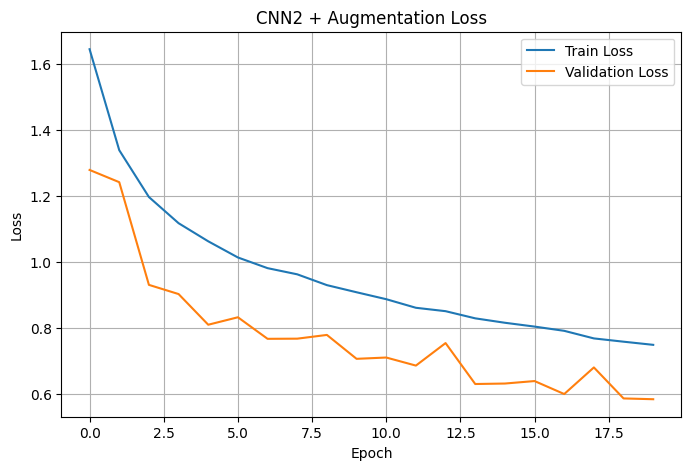

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_aug,
    label="Train Loss"
)

plt.plot(
    val_losses_aug,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN2 + Augmentation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

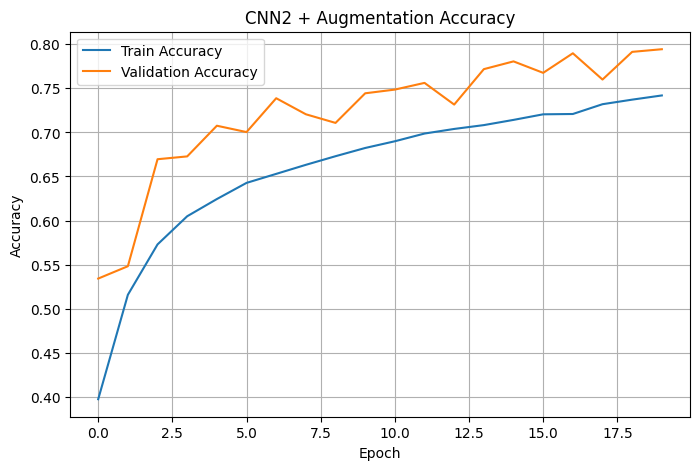

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs_aug,
    label="Train Accuracy"
)

plt.plot(
    val_accs_aug,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "CNN2 + Augmentation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [66]:
val_sub_wrong = Subset(
    train_dataset_aug,
    val_idx
)

val_loader_wrong = DataLoader(
    val_sub_wrong,
    batch_size=64,
    shuffle=False
)

wrong_loss, wrong_acc, wrong_f1 = evaluate_f1(
    model_aug,
    val_loader_wrong,
    criterion,
    device
)

print("Correct Validation Accuracy :", val_acc_aug)
print("Wrong Validation Accuracy   :", wrong_acc)

print("Correct Validation F1 :", val_f1_aug)
print("Wrong Validation F1   :", wrong_f1)

Correct Validation Accuracy : 0.7944
Wrong Validation Accuracy   : 0.78
Correct Validation F1 : 0.7944075566807758
Wrong Validation F1   : 0.780005813131595


# <div dir = 'rtl'>مدل RESNET</div>

In [67]:
transform_resnet_train = transforms.Compose([

    transforms.Resize((96,96)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

transform_resnet_test = transforms.Compose([

    transforms.Resize((96,96)),

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

In [68]:
train_dataset_resnet = datasets.CIFAR10(
    root="./cifar-10-python",
    train=True,
    download=False,
    transform=transform_resnet_train
)

test_dataset_resnet = datasets.CIFAR10(
    root="./cifar-10-python",
    train=False,
    download=False,
    transform=transform_resnet_test
)

train_sub_resnet = Subset(
    train_dataset_resnet,
    train_idx
)

val_sub_resnet = Subset(
    datasets.CIFAR10(
        root="./cifar-10-python",
        train=True,
        download=False,
        transform=transform_resnet_test
    ),
    val_idx
)

In [69]:
train_loader_resnet = DataLoader(
    train_sub_resnet,
    batch_size=64,
    shuffle=True
)

val_loader_resnet = DataLoader(
    val_sub_resnet,
    batch_size=64,
    shuffle=False
)

In [70]:
resnet18 = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

In [71]:
for param in resnet18.parameters():
    
    param.requires_grad = False

In [72]:
num_features = resnet18.fc.in_features

resnet18.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        num_features,
        10
    )
)

In [73]:
resnet18 = resnet18.to(device)

In [74]:
criterion = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.Adam(
    resnet18.fc.parameters(),
    lr=1e-3
)

In [75]:
for epoch in range(10):
    
    train_loss, train_acc = train_one_epoch(
        resnet18,
        train_loader_resnet,
        criterion,
        optimizer_resnet,
        device
    )

    val_loss, val_acc = evaluate(
        resnet18,
        val_loader_resnet,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1} "
        f"Train Acc {train_acc:.4f} "
        f"Val Acc {val_acc:.4f}"
    )

Epoch 1 Train Acc 0.5940 Val Acc 0.7354
Epoch 2 Train Acc 0.6504 Val Acc 0.7392
Epoch 3 Train Acc 0.6524 Val Acc 0.7306
Epoch 4 Train Acc 0.6534 Val Acc 0.7398
Epoch 5 Train Acc 0.6506 Val Acc 0.7362
Epoch 6 Train Acc 0.6512 Val Acc 0.7422
Epoch 7 Train Acc 0.6548 Val Acc 0.7458
Epoch 8 Train Acc 0.6529 Val Acc 0.7472
Epoch 9 Train Acc 0.6527 Val Acc 0.7392
Epoch 10 Train Acc 0.6542 Val Acc 0.7446


In [76]:
for param in resnet18.layer4.parameters():
    
    param.requires_grad = True

In [77]:
optimizer_ft = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        resnet18.parameters()
    ),

    lr=1e-4
)

In [78]:
for epoch in range(5):
    
    train_loss, train_acc = train_one_epoch(
        resnet18,
        train_loader_resnet,
        criterion,
        optimizer_ft,
        device
    )

    val_loss, val_acc = evaluate(
        resnet18,
        val_loader_resnet,
        criterion,
        device
    )

    print(
        f"FineTune Epoch {epoch+1} "
        f"Val Acc {val_acc:.4f}"
    )

FineTune Epoch 1 Val Acc 0.8752
FineTune Epoch 2 Val Acc 0.8906
FineTune Epoch 3 Val Acc 0.8990
FineTune Epoch 4 Val Acc 0.8990
FineTune Epoch 5 Val Acc 0.9060


In [79]:
test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=64,
    shuffle=False
)

test_loss_resnet, test_acc_resnet, test_f1_resnet = evaluate_f1(
    resnet18,
    test_loader_resnet,
    criterion,
    device
)

print("ResNet18 Accuracy :", test_acc_resnet)
print("ResNet18 Macro F1 :", test_f1_resnet)

ResNet18 Accuracy : 0.9016
ResNet18 Macro F1 : 0.9016182876090839
